# 07_XGBoost_tuning_threshold

### 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import joblib
import os
import time

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

### 2. Load data and reproduce the same split

In [2]:
data = pd.read_csv(
    'feature_engineered_data.csv'
)

data['HAS_BUREAU_HISTORY'] = (
    data['BUREAU_LOAN_COUNT'].notna()
).astype(int)

data = data.drop(
    columns=['SK_ID_CURR']
)

X = data.drop(columns='TARGET')
y = data['TARGET']

In [3]:
# Reproduce the original train/test split:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [4]:
# Reproduce the train/validation split:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (32000, 143)
Validation: (8000, 143)
Test: (10000, 143)


### 3. Remove the same high-missingness columns

In [5]:
missing_percentage = (
    X_train_full
    .isnull()
    .mean()
    .mul(100)
)

high_missing_columns = (
    missing_percentage[
        missing_percentage > 60
    ]
    .index
    .tolist()
)

X_train = X_train.drop(
    columns=high_missing_columns
)

X_val = X_val.drop(
    columns=high_missing_columns
)

X_test = X_test.drop(
    columns=high_missing_columns
)

print(
    "High-Missingness Columns:",
    len(high_missing_columns)
)

High-Missingness Columns: 17


### 4. Load tree-model features

In [6]:
tree_num_features = joblib.load(
    'models/tree_numerical_features.joblib'
)

tree_cat_features = joblib.load(
    'models/tree_categorical_features.joblib'
)

print(
    "Tree Numerical Features:",
    len(tree_num_features)
)

print(
    "Tree Categorical Features:",
    len(tree_cat_features)
)

Tree Numerical Features: 93
Tree Categorical Features: 15


In [8]:
# Validate:
selected_tree_features = (
    tree_num_features
    + tree_cat_features
)

missing_features = [
    feature
    for feature in selected_tree_features
    if feature not in X_train.columns
]

print("Missing Features:", missing_features)

Missing Features: []


# Part A: Preprocessing
### 5. Create preprocessing pipeline

In [9]:
tree_numerical_pipeline = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(
                strategy='median'
            )
        )
    ]
)

In [10]:
tree_categorical_pipeline = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(
                strategy='most_frequent'
            )
        ),

        (
            'encoder',
            OneHotEncoder(
                handle_unknown='ignore'
            )
        )
    ]
)

In [11]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            tree_numerical_pipeline,
            tree_num_features
        ),

        (
            'cat',
            tree_categorical_pipeline,
            tree_cat_features
        )
    ]
)

### 6. Calculate scale_pos_weight

In [12]:
negative_count = (
    y_train == 0
).sum()

positive_count = (
    y_train == 1
).sum()

scale_pos_weight = (
    negative_count
    / positive_count
)

print(
    "scale_pos_weight:",
    scale_pos_weight
)

scale_pos_weight: 11.417539774932091


# Part B: Randomized Hyperparameter Search
### 7. Create XGBoost pipeline

Keep the base model simple because the search will set the important hyperparameters.

In [13]:
xgb_pipeline = Pipeline(
    steps=[
        (
            'preprocessor',
            tree_preprocessor
        ),

        (
            'classifier',
            XGBClassifier(
                objective='binary:logistic',
                eval_metric='logloss',
                scale_pos_weight=scale_pos_weight,
                n_jobs=1,
                random_state=42
            )
        )
    ]
)

### 8. Define the parameter distributions

In [14]:
param_distributions = {

    'classifier__n_estimators': [
        200,
        300,
        400,
        500
    ],

    'classifier__max_depth': [
        3,
        4,
        5,
        6
    ],

    'classifier__learning_rate': [
        0.02,
        0.05,
        0.08,
        0.10
    ],

    'classifier__min_child_weight': [
        1,
        3,
        5,
        7
    ],

    'classifier__subsample': [
        0.7,
        0.8,
        0.9,
        1.0
    ],

    'classifier__colsample_bytree': [
        0.7,
        0.8,
        0.9,
        1.0
    ],

    'classifier__gamma': [
        0,
        0.1,
        0.3,
        0.5
    ],

    'classifier__reg_alpha': [
        0,
        0.01,
        0.1,
        0.5
    ],

    'classifier__reg_lambda': [
        1,
        2,
        5,
        10
    ]
}

### 9. Create RandomizedSearchCV


In [15]:
random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    return_train_score=True,
    refit=True
)

### 10. Run tuning

In [16]:
start_time = time.time()

random_search.fit(
    X_train,
    y_train
)

tuning_time = (
    time.time() - start_time
)

print(
    "Tuning Time:",
    round(tuning_time, 2),
    "seconds"
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Tuning Time: 193.36 seconds


### 11. Inspect best CV results

In [17]:
print(
    "Best CV ROC-AUC:",
    random_search.best_score_
)

print(
    "\nBest Parameters:"
)

random_search.best_params_

Best CV ROC-AUC: 0.7472522034138821

Best Parameters:


{'classifier__subsample': 0.7,
 'classifier__reg_lambda': 10,
 'classifier__reg_alpha': 0.01,
 'classifier__n_estimators': 300,
 'classifier__min_child_weight': 7,
 'classifier__max_depth': 3,
 'classifier__learning_rate': 0.02,
 'classifier__gamma': 0,
 'classifier__colsample_bytree': 0.9}

In [18]:
# Save the search results:
cv_results = pd.DataFrame(
    random_search.cv_results_
)

cv_results[
    [
        'rank_test_score',
        'mean_train_score',
        'mean_test_score',
        'std_test_score',
        'params'
    ]
].sort_values(
    'rank_test_score'
).head(10)

,rank_test_score,mean_train_score,mean_test_score,std_test_score,params
2,1,0.801410,0.747252,0.006168,"{'classifier__subsample': 0.7, 'classifier__re..."
12,2,0.847484,0.746964,0.006690,"{'classifier__subsample': 0.9, 'classifier__re..."
10,3,0.827984,0.746445,0.006163,"{'classifier__subsample': 0.9, 'classifier__re..."
3,4,0.872791,0.746055,0.006269,"{'classifier__subsample': 0.9, 'classifier__re..."
8,5,0.903817,0.742235,0.006558,"{'classifier__subsample': 0.9, 'classifier__re..."
19,6,0.900782,0.737431,0.007876,"{'classifier__subsample': 0.9, 'classifier__re..."
5,7,0.897723,0.737041,0.007773,"{'classifier__subsample': 1.0, 'classifier__re..."
13,8,0.944227,0.736033,0.006614,"{'classifier__subsample': 0.9, 'classifier__re..."
9,9,0.958280,0.735580,0.006715,"{'classifier__subsample': 0.8, 'classifier__re..."
4,10,0.958475,0.730699,0.008977,"{'classifier__subsample': 0.9, 'classifier__re..."


In [19]:
# Save
os.makedirs(
    'reports',
    exist_ok=True
)

cv_results.to_csv(
    'reports/xgboost_random_search_results.csv',
    index=False
)

# Part C: Compare Tuned and Baseline XGBoost
### 12. Get the tuned model

In [20]:
tuned_xgboost_model = (
    random_search.best_estimator_
)

In [21]:
# Validation probabilities:
tuned_val_probability = (
    tuned_xgboost_model.predict_proba(
        X_val
    )[:, 1]
)

In [22]:
# Load baseline:
baseline_xgboost_model = joblib.load(
    'models/baseline_xgboost.joblib'
)

In [23]:
baseline_val_probability = (
    baseline_xgboost_model.predict_proba(
        X_val
    )[:, 1]
)

### 13. Compare ranking metrics

In [24]:
model_comparison = pd.DataFrame({
    'MODEL': [
        'Baseline XGBoost',
        'Tuned XGBoost'
    ],

    'ROC_AUC': [
        roc_auc_score(
            y_val,
            baseline_val_probability
        ),

        roc_auc_score(
            y_val,
            tuned_val_probability
        )
    ],

    'PR_AUC': [
        average_precision_score(
            y_val,
            baseline_val_probability
        ),

        average_precision_score(
            y_val,
            tuned_val_probability
        )
    ]
})

model_comparison

,MODEL,ROC_AUC,PR_AUC
0,Baseline XGBoost,0.751337,0.247681
1,Tuned XGBoost,0.752809,0.247865


In [25]:
### Add improvement columns:
roc_improvement = (
    model_comparison.loc[
        model_comparison['MODEL']
        == 'Tuned XGBoost',
        'ROC_AUC'
    ].iloc[0]

    -

    model_comparison.loc[
        model_comparison['MODEL']
        == 'Baseline XGBoost',
        'ROC_AUC'
    ].iloc[0]
)

pr_improvement = (
    model_comparison.loc[
        model_comparison['MODEL']
        == 'Tuned XGBoost',
        'PR_AUC'
    ].iloc[0]

    -

    model_comparison.loc[
        model_comparison['MODEL']
        == 'Baseline XGBoost',
        'PR_AUC'
    ].iloc[0]
)

print(
    "ROC-AUC Improvement:",
    round(roc_improvement, 4)
)

print(
    "PR-AUC Improvement:",
    round(pr_improvement, 4)
)

ROC-AUC Improvement: 0.0015
PR-AUC Improvement: 0.0002


# Part D: Threshold Selection
### 14. Why threshold tuning?

The model outputs probabilities:

P(default)

The default rule is:

Probability >= 0.50 → Default

But 0.50 is arbitrary for an imbalanced credit-risk problem.

A lower threshold generally increases recall but creates more false positives.

We will compare thresholds on the validation set.

### 15. Evaluate a threshold grid

In [26]:
if (
    average_precision_score(
        y_val,
        tuned_val_probability
    )
    >=
    average_precision_score(
        y_val,
        baseline_val_probability
    )
):
    selected_model = tuned_xgboost_model
    selected_val_probability = (
        tuned_val_probability
    )
    selected_model_name = (
        'Tuned XGBoost'
    )

else:
    selected_model = baseline_xgboost_model
    selected_val_probability = (
        baseline_val_probability
    )
    selected_model_name = (
        'Baseline XGBoost'
    )

print(
    "Selected Model:",
    selected_model_name
)

Selected Model: Tuned XGBoost


In [27]:
# Now evaluate thresholds:
thresholds = np.arange(
    0.10,
    0.81,
    0.01
)

threshold_results = []

for threshold in thresholds:

    predictions = (
        selected_val_probability
        >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        predictions
    ).ravel()

    threshold_results.append({

        'THRESHOLD':
            threshold,

        'PRECISION':
            precision_score(
                y_val,
                predictions,
                zero_division=0
            ),

        'RECALL':
            recall_score(
                y_val,
                predictions,
                zero_division=0
            ),

        'F1_SCORE':
            f1_score(
                y_val,
                predictions,
                zero_division=0
            ),

        'BALANCED_ACCURACY':
            balanced_accuracy_score(
                y_val,
                predictions
            ),

        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp
    })

threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results.head()

,THRESHOLD,PRECISION,RECALL,F1_SCORE,BALANCED_ACCURACY,TN,FP,FN,TP
0,0.10,0.080816,0.996894,0.149511,0.502118,54,7302,2,642
1,0.11,0.081317,0.996894,0.150369,0.505448,103,7253,2,642
2,0.12,0.081708,0.995342,0.151019,0.508003,152,7204,3,641
3,0.13,0.082306,0.995342,0.152040,0.511877,209,7147,3,641
4,0.14,0.082815,0.992236,0.152871,0.515082,279,7077,5,639


### 16. Find threshold maximizing F1

In [28]:
best_f1_row = threshold_results.loc[
    threshold_results[
        'F1_SCORE'
    ].idxmax()
]

best_f1_row

THRESHOLD               0.650000
PRECISION               0.269430
RECALL                  0.403727
F1_SCORE                0.323182
BALANCED_ACCURACY       0.653943
TN                   6651.000000
FP                    705.000000
FN                    384.000000
TP                    260.000000
Name: 55, dtype: float64

### 17. Find threshold maximizing balanced accuracy

In [29]:
best_balanced_accuracy_row = (
    threshold_results.loc[
        threshold_results[
            'BALANCED_ACCURACY'
        ].idxmax()
    ]
)

best_balanced_accuracy_row

THRESHOLD               0.540000
PRECISION               0.192647
RECALL                  0.610248
F1_SCORE                0.292846
BALANCED_ACCURACY       0.693175
TN                   5709.000000
FP                   1647.000000
FN                    251.000000
TP                    393.000000
Name: 44, dtype: float64

### 18. Find a recall-constrained threshold

In [30]:
recall_constraint = 0.70

eligible_thresholds = (
    threshold_results[
        threshold_results['RECALL']
        >= recall_constraint
    ]
)

if len(eligible_thresholds) > 0:

    recall_constrained_row = (
        eligible_thresholds.loc[
            eligible_thresholds[
                'PRECISION'
            ].idxmax()
        ]
    )

    display(recall_constrained_row)

else:
    print(
        "No threshold achieved the recall constraint."
    )

THRESHOLD               0.470000
PRECISION               0.152537
RECALL                  0.709627
F1_SCORE                0.251099
BALANCED_ACCURACY       0.682233
TN                   4817.000000
FP                   2539.000000
FN                    187.000000
TP                    457.000000
Name: 37, dtype: float64

### 19. Plot threshold trade-offs

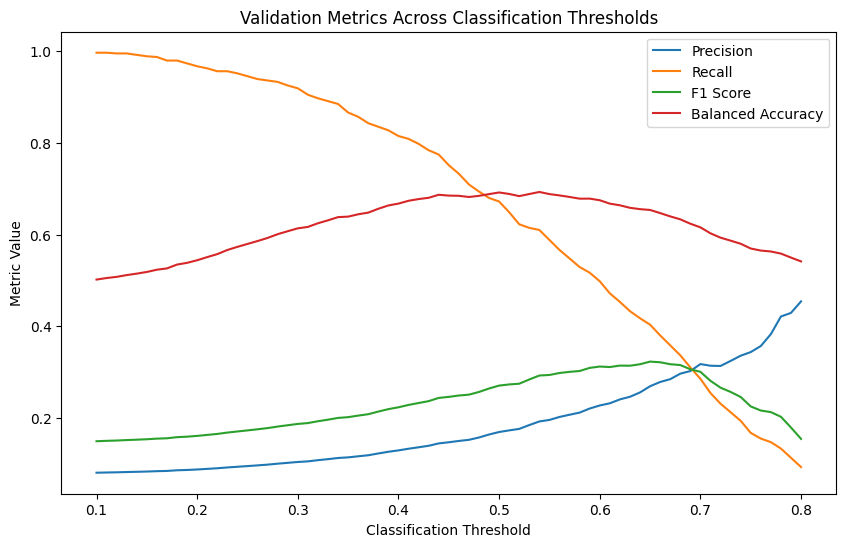

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results['THRESHOLD'],
    threshold_results['PRECISION'],
    label='Precision'
)

plt.plot(
    threshold_results['THRESHOLD'],
    threshold_results['RECALL'],
    label='Recall'
)

plt.plot(
    threshold_results['THRESHOLD'],
    threshold_results['F1_SCORE'],
    label='F1 Score'
)

plt.plot(
    threshold_results['THRESHOLD'],
    threshold_results[
        'BALANCED_ACCURACY'
    ],
    label='Balanced Accuracy'
)

plt.xlabel('Classification Threshold')
plt.ylabel('Metric Value')

plt.title(
    'Validation Metrics Across Classification Thresholds'
)

plt.legend()
plt.show()

### 20. Choose the final threshold

In [32]:
minimum_recall = 0.60

eligible_final_thresholds = (
    threshold_results[
        threshold_results['RECALL']
        >= minimum_recall
    ]
)

final_threshold_row = (
    eligible_final_thresholds.loc[
        eligible_final_thresholds[
            'F1_SCORE'
        ].idxmax()
    ]
)

final_threshold = (
    final_threshold_row[
        'THRESHOLD'
    ]
)

print(
    "Selected Final Threshold:",
    final_threshold
)

final_threshold_row

Selected Final Threshold: 0.5399999999999998


THRESHOLD               0.540000
PRECISION               0.192647
RECALL                  0.610248
F1_SCORE                0.292846
BALANCED_ACCURACY       0.693175
TN                   5709.000000
FP                   1647.000000
FN                    251.000000
TP                    393.000000
Name: 44, dtype: float64

### 21. Validation classification report at selected threshold

In [33]:
selected_val_predictions = (
    selected_val_probability
    >= final_threshold
).astype(int)

print(
    classification_report(
        y_val,
        selected_val_predictions,
        digits=3
    )
)

print(
    confusion_matrix(
        y_val,
        selected_val_predictions
    )
)

              precision    recall  f1-score   support

           0      0.958     0.776     0.857      7356
           1      0.193     0.610     0.293       644

    accuracy                          0.763      8000
   macro avg      0.575     0.693     0.575      8000
weighted avg      0.896     0.763     0.812      8000

[[5709 1647]
 [ 251  393]]


### 22. Save the selected model, threshold, and results

In [34]:
joblib.dump(
    selected_model,
    'models/selected_xgboost_model.joblib'
)

joblib.dump(
    final_threshold,
    'models/final_classification_threshold.joblib'
)

threshold_results.to_csv(
    'reports/validation_threshold_results.csv',
    index=False
)

model_comparison.to_csv(
    'reports/xgboost_tuning_comparison.csv',
    index=False
)

# XGBoost Tuning and Threshold Selection Summary

1. XGBoost hyperparameters were optimized using RandomizedSearchCV with three-fold cross-validation on the training data.

2. ROC-AUC was used as the hyperparameter-search objective because it evaluates ranking performance independently of a classification threshold.

3. The tuned XGBoost model was compared with the baseline model on the held-out validation set using both ROC-AUC and PR-AUC.

4. The model with stronger validation PR-AUC was retained for threshold analysis.

5. Multiple classification thresholds were evaluated on the validation set using precision, recall, F1-score, balanced accuracy, and confusion-matrix counts.

6. Threshold selection was constrained to maintain at least 60% recall, after which the threshold with the highest F1-score was selected.

7. The selected model and classification threshold were frozen before accessing the untouched test set.

8. Final test evaluation and model interpretation were deferred to the next notebook.

### XGBoost Tuning and Threshold Selection — Observations

- RandomizedSearchCV achieved a best cross-validation ROC-AUC of approximately 0.747.

- The tuned XGBoost model achieved a validation ROC-AUC of approximately 0.753 and PR-AUC of 0.248, marginally outperforming the baseline XGBoost model.

- The modest improvement indicated that the baseline XGBoost configuration was already competitive and that extensive hyperparameter tuning produced limited additional ranking performance.

- The selected hyperparameters favored a shallow, regularized model with a low learning rate, suggesting that controlling model complexity was beneficial for generalization.

- Classification-threshold analysis demonstrated a clear trade-off between precision and recall.

- The threshold maximizing F1-score was approximately 0.65, while the threshold maximizing balanced accuracy was approximately 0.54.

- A threshold of approximately 0.47 provided the highest precision among thresholds achieving at least 70% recall.

- The final classification threshold was selected as approximately 0.54 by maximizing validation F1-score subject to a minimum recall requirement of 60%.

- At the selected threshold, the tuned model achieved approximately 19.3% precision, 61.0% recall, and an F1-score of 0.293 on the validation set.

- The selected model and threshold were frozen before evaluating performance on the untouched test set.